Name | Surname | index
-|-|-
Natan | Jabłoński | 155621

# Vital imports 

In [1]:
import inspect
from veinClassifier.dataset import EyeDataset
from veinClassifier.patchDataset import PatchDataset
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from veinClassifier.models.basicConv import BasicConv
from veinClassifier.models.basicUnet import UNet

from veinClassifier.presentation import eval_model, eval_model_inline, predict_test_images
from veinClassifier.utils import run_epoch, train_model, plot_history, compute_pos_weight

# Original dataset

## Dataset preparation

In [2]:
project_root = Path().cwd().parent

dataset = EyeDataset(project_root / "data/healthy_filtered/", project_root / "data/healthy_manualsegm")

img, segm = dataset[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Train-test split 

In [3]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_patch_dataset = PatchDataset(
    train_dataset,
    patch_size=256
)

train_loader = DataLoader(
    train_patch_dataset,
    batch_size=5,
    shuffle=True
)

# train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Simple convolutional neural networ

## Training

Epoch 01: train_loss=1.232 val_loss=1.046 train_f1=0.273 val_f1=0.173
Epoch 02: train_loss=1.184 val_loss=1.043 train_f1=0.236 val_f1=0.173
Epoch 03: train_loss=1.228 val_loss=1.041 train_f1=0.264 val_f1=0.173
Epoch 04: train_loss=1.247 val_loss=1.039 train_f1=0.272 val_f1=0.173
Epoch 05: train_loss=1.143 val_loss=1.037 train_f1=0.227 val_f1=0.174
Epoch 06: train_loss=1.072 val_loss=1.034 train_f1=0.195 val_f1=0.174
Epoch 07: train_loss=1.061 val_loss=1.029 train_f1=0.193 val_f1=0.182
Epoch 08: train_loss=1.175 val_loss=1.025 train_f1=0.449 val_f1=0.076
Epoch 09: train_loss=1.066 val_loss=1.022 train_f1=0.172 val_f1=0.000
Epoch 10: train_loss=1.332 val_loss=1.019 train_f1=0.014 val_f1=0.000
Epoch 11: train_loss=1.081 val_loss=1.017 train_f1=0.013 val_f1=0.000
Epoch 12: train_loss=1.049 val_loss=1.014 train_f1=0.004 val_f1=0.000
Epoch 13: train_loss=1.117 val_loss=1.010 train_f1=0.000 val_f1=0.000
Epoch 14: train_loss=1.186 val_loss=1.006 train_f1=0.000 val_f1=0.000
Epoch 15: train_loss

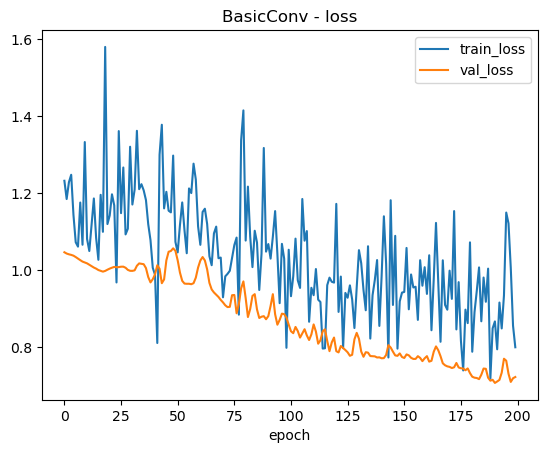

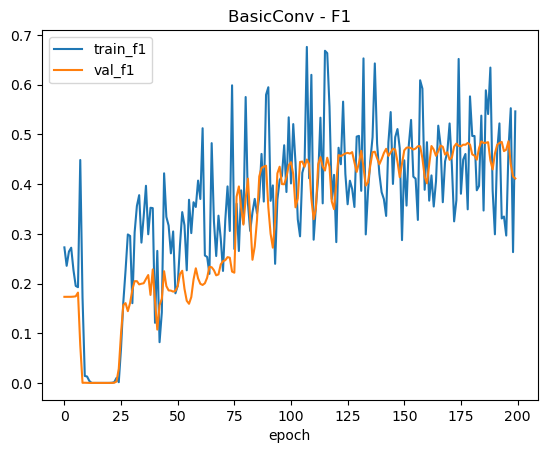

In [4]:

model = BasicConv(in_channels=3, out_channels=1)

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

basicConv, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "BasicConv")

torch.save(
    basicConv.state_dict(),
    project_root / "savedModels/basicConv.pth"
)

# Evaluation

In [5]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("BasicConv (val)", val_y, val_pred)
eval_model_inline("BasicConv (test)", test_y, test_pred)

[BasicConv (val)] accuracy=0.813 f1=0.411 precision=0.294 recall=0.687
[BasicConv (test)] accuracy=0.678 f1=0.304 precision=0.190 recall=0.754


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:03<00:00, 12.62s/it]


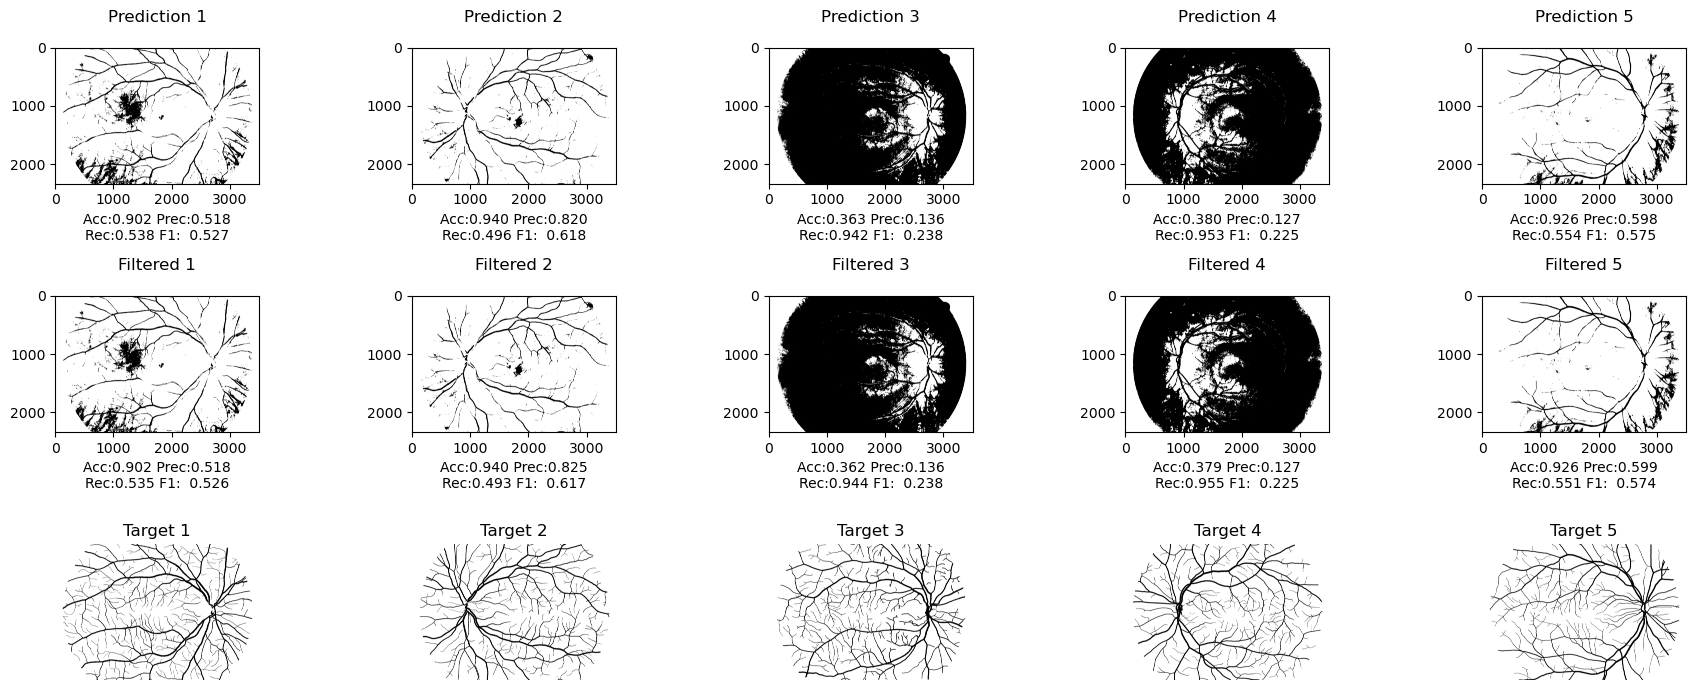


Average metrics for Prediction:
Accuracy : 0.7021
Precision: 0.4400
Recall   : 0.6965
F1 Score : 0.4367

Average metrics for Filtered:
Accuracy : 0.7017
Precision: 0.4413
Recall   : 0.6953
F1 Score : 0.4360


In [6]:
predict_test_images(model, dataset, device)

## Simple UNet

## Training

Epoch 01: train_loss=1.318 val_loss=0.957 train_f1=0.000 val_f1=0.000
Epoch 02: train_loss=1.014 val_loss=0.958 train_f1=0.000 val_f1=0.000
Epoch 03: train_loss=1.164 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 04: train_loss=1.088 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 05: train_loss=1.085 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 06: train_loss=1.086 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 07: train_loss=1.078 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 08: train_loss=1.195 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 09: train_loss=1.097 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 10: train_loss=0.996 val_loss=0.959 train_f1=0.000 val_f1=0.000
Epoch 11: train_loss=1.010 val_loss=0.958 train_f1=0.000 val_f1=0.000
Epoch 12: train_loss=1.050 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 13: train_loss=1.178 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 14: train_loss=1.204 val_loss=0.956 train_f1=0.000 val_f1=0.000
Epoch 15: train_loss

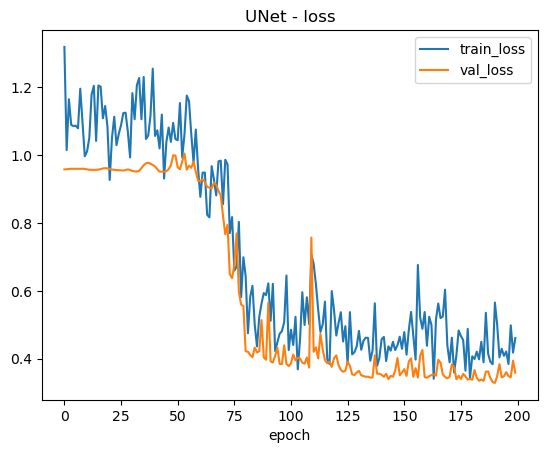

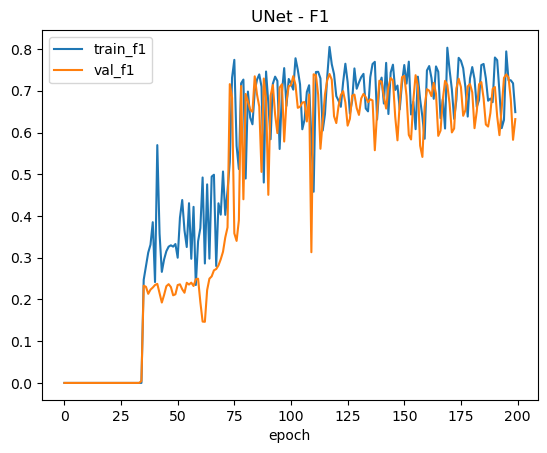

In [7]:

model = UNet()

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

model, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "UNet")

torch.save(
    model.state_dict(),
    project_root / "savedModels/UNet.pth"
)

# Evaluation

In [8]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("Unet (val)", val_y, val_pred)
eval_model_inline("Unet (test)", test_y, test_pred)

[Unet (val)] accuracy=0.900 f1=0.632 precision=0.486 recall=0.903
[Unet (test)] accuracy=0.876 f1=0.581 precision=0.423 recall=0.927


### Test 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:03<00:00, 12.71s/it]


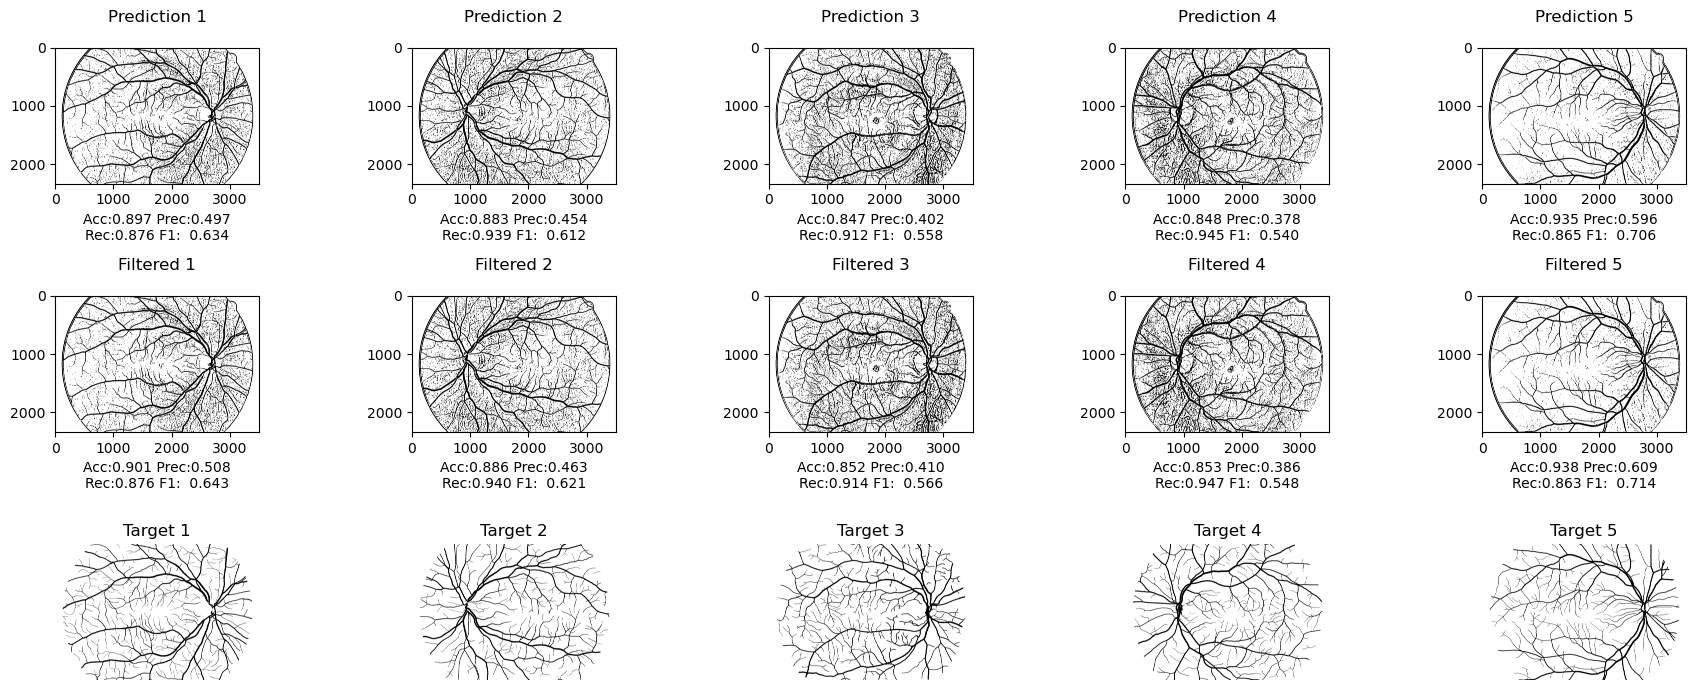


Average metrics for Prediction:
Accuracy : 0.8820
Precision: 0.4654
Recall   : 0.9075
F1 Score : 0.6100

Average metrics for Filtered:
Accuracy : 0.8860
Precision: 0.4752
Recall   : 0.9079
F1 Score : 0.6184


In [9]:
predict_test_images(model, dataset, device)

# Augumented dataset

## Dataset preparation

In [10]:
project_root = Path().cwd().parent

dataset = EyeDataset(project_root / "data/healthy_aug_filtered/", project_root / "data/healthy_aug_manualsegm")

img, segm = dataset[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Train-test split 

In [11]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_patch_dataset = PatchDataset(
    train_dataset,
    patch_size=256
)

train_loader = DataLoader(
    train_patch_dataset,
    batch_size=5,
    shuffle=True
)

# train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

## Simple convolutional neural network

## Training

In [ ]:

model = BasicConv(in_channels=3, out_channels=1)

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

basicConv, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "BasicConv")

torch.save(
    basicConv.state_dict(),
    project_root / "savedModels/basicConv_aug.pth"
)

Epoch 01: train_loss=1.055 val_loss=0.987 train_f1=0.165 val_f1=0.000


# Evaluation

In [ ]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("BasicConv (val)", val_y, val_pred)
eval_model_inline("BasicConv (test)", test_y, test_pred)

### Test 

In [ ]:
predict_test_images(model, dataset, device)

## Simple UNet

## Training

In [ ]:

model = UNet()

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)

model, hist_basicConv = train_model(model, train_loader, val_loader, criterion, device, lr=1e-3, epochs=200)
plot_history(hist_basicConv, "UNet")

torch.save(
    model.state_dict(),
    project_root / "savedModels/UNet_aug.pth"
)

# Evaluation

In [ ]:
# basicConv = BasicConv(
#     in_channels=3,
#     out_channels=1
# )
# basicConv.load_state_dict(
#     torch.load(
#         project_root / "savedModels/basicConv.pth",
#         map_location=device
#     )
# )

val_loss, val_y, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)
test_loss, test_y, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

eval_model_inline("Unet (val)", val_y, val_pred)
eval_model_inline("Unet (test)", test_y, test_pred)

### Test 

In [ ]:
predict_test_images(model, dataset, device)